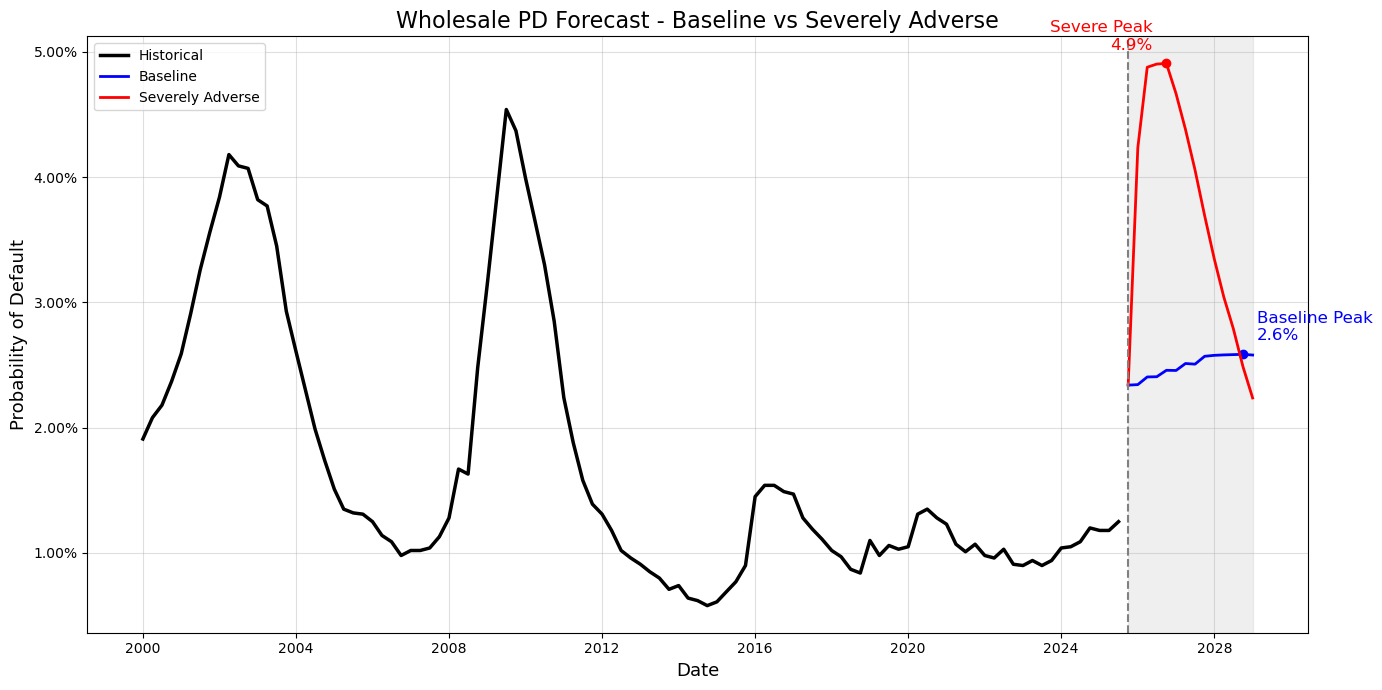

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Load files
baseline = pd.read_csv("Probability Default - Baseline.csv")
severe = pd.read_csv("Probability Default - Severely Adverse.csv")

# Clean column names
baseline.columns = baseline.columns.str.strip()
severe.columns = severe.columns.str.strip()

# Convert Quarter to datetime
baseline["Date"] = pd.PeriodIndex(baseline["Quarter"], freq="Q").to_timestamp()
severe["Date"] = pd.PeriodIndex(severe["Quarter"], freq="Q").to_timestamp()

# Split history and forecast
hist_end = pd.Period("2025Q3", freq="Q").to_timestamp()
fcst_start = pd.Period("2025Q4", freq="Q").to_timestamp()

baseline_hist = baseline[baseline["Date"] <= hist_end].copy()
baseline_fcst = baseline[baseline["Date"] >= fcst_start].copy()
severe_fcst = severe[severe["Date"] >= fcst_start].copy()

# Use baseline history as common history
history = baseline_hist.copy()

# Plot
plt.figure(figsize=(14, 7))

# --- Highlight forecast region ---
plt.axvspan(
    fcst_start,
    baseline_fcst["Date"].max(),
    color="gray",
    alpha=0.12
)

# Historical
plt.plot(
    history["Date"],
    history["Probability of Default"],
    color="black",
    linewidth=2.5,
    label="Historical"
)

# Baseline
plt.plot(
    baseline_fcst["Date"],
    baseline_fcst["Probability of Default"],
    color="blue",
    linewidth=2,
    label="Baseline"
)

# Severe
plt.plot(
    severe_fcst["Date"],
    severe_fcst["Probability of Default"],
    color="red",
    linewidth=2,
    label="Severely Adverse"
)

# Forecast divider
plt.axvline(fcst_start, color="gray", linestyle="--", linewidth=1.5)

# Baseline peak
baseline_peak_idx = baseline_fcst["Probability of Default"].idxmax()
baseline_peak_date = baseline_fcst.loc[baseline_peak_idx, "Date"]
baseline_peak_val = baseline_fcst.loc[baseline_peak_idx, "Probability of Default"]

plt.scatter(baseline_peak_date, baseline_peak_val, color="blue")
plt.annotate(
    f"Baseline Peak\n{baseline_peak_val:.1%}",
    (baseline_peak_date, baseline_peak_val),
    textcoords="offset points",
    xytext=(10, 10),
    ha="left",
    color="blue",
    fontsize=12
)

# Severe peak
severe_peak_idx = severe_fcst["Probability of Default"].idxmax()
severe_peak_date = severe_fcst.loc[severe_peak_idx, "Date"]
severe_peak_val = severe_fcst.loc[severe_peak_idx, "Probability of Default"]

plt.scatter(severe_peak_date, severe_peak_val, color="red")
plt.annotate(
    f"Severe Peak\n{severe_peak_val:.1%}",
    (severe_peak_date, severe_peak_val),
    textcoords="offset points",
    xytext=(-10, 10),
    ha="right",
    color="red",
    fontsize=12
)

# X-axis ticks every 4 years
years = pd.date_range(start="2000-01-01", end="2029-01-01", freq="4YS")
plt.xticks(years, [d.year for d in years])

# Y-axis as percent
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

# Labels
plt.title("Wholesale PD Forecast - Baseline vs Severely Adverse")
plt.xlabel("Date")
plt.ylabel("Probability of Default")

plt.title("Wholesale PD Forecast - Baseline vs Severely Adverse", fontsize=16)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Probability of Default", fontsize=13)

plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("wholesale_pd_forecast.png", dpi=300)
plt.show()